# Fake News Detection - End-to-End NLP Project

A small classifier that reads a news headline and decides if it is fake (0) or real (1). The whole pipeline lives in this one notebook so it is easy to follow from start to finish.

### The pipeline at a glance

```
raw csv  ->  clean  ->  preprocess  ->  vectorise  ->  train  ->  evaluate  ->  predict
```


## Setup

All the imports we share across the notebook. If you need something specific to your section, add it inside that section.

In [1]:
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

import joblib

# Run these once, then comment them out
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt')

RANDOM_STATE = 42
pd.set_option('display.max_colwidth', 120)

---
# 1. The data

Two files in `dataset/`:

- `training_data_lowercase.csv` - has `label` and `headline`. Labels are 0 (fake) or 1 (real). This is what we train on.
- `testing_data_lowercase_nolabels.csv` - just `headline`. No labels - this is what we have to predict.

---
# 2. Loading and cleaning the data

In [2]:
TRAIN_PATH = 'dataset/training_data_lowercase.csv'
TEST_PATH = 'dataset/testing_data_lowercase_nolabels.csv'

# The files are tab-separated and have no header row
df_train = pd.read_csv(TRAIN_PATH, sep='\t', header=None, names=['label', 'headline'])
df_test = pd.read_csv(TEST_PATH, sep='\t', header=None, names=['headline'])

print('Train shape:', df_train.shape)
print('Test  shape:', df_test.shape)
df_train.head()

Train shape: (34152, 2)
Test  shape: (9984, 1)


,label,headline
0,0,donald trump sends out embarrassing new year‚s eve message; this is disturbing
1,0,drunk bragging trump staffer started russian collusion investigation
2,0,sheriff david clarke becomes an internet joke for threatening to poke people ‚in the eye‚
3,0,trump is so obsessed he even has obama‚s name coded into his website (images)
4,0,pope francis just called out donald trump during his christmas speech


In [3]:
print('Missing in train:')
print(df_train.isna().sum())
print('\nMissing in test:')
print(df_test.isna().sum())

n_dup = df_train.duplicated().sum()
print(f'\nDuplicate rows in train: {n_dup}')
df_train = df_train.drop_duplicates().reset_index(drop=True)

df_train['label'] = df_train['label'].astype(int)
df_train['headline'] = df_train['headline'].astype(str)
df_test['headline'] = df_test['headline'].astype(str)

df_train.info()

Missing in train:
label       0
headline    0
dtype: int64

Missing in test:
headline    0
dtype: int64

Duplicate rows in train: 1946
<class 'pandas.DataFrame'>
RangeIndex: 32206 entries, 0 to 32205
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   label     32206 non-null  int64
 1   headline  32206 non-null  str  
dtypes: int64(1), str(1)
memory usage: 503.3 KB


## 2.1 A quick look at the data (EDA)

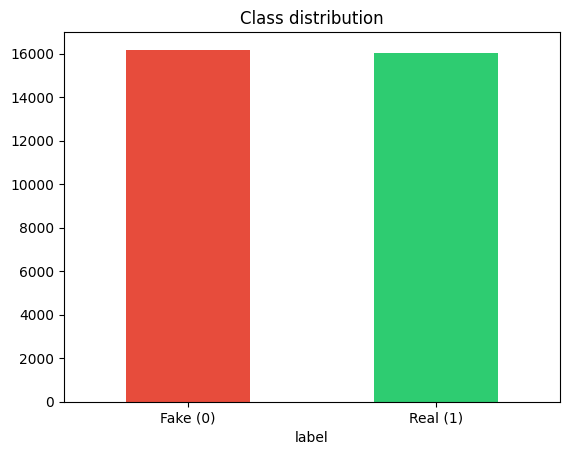

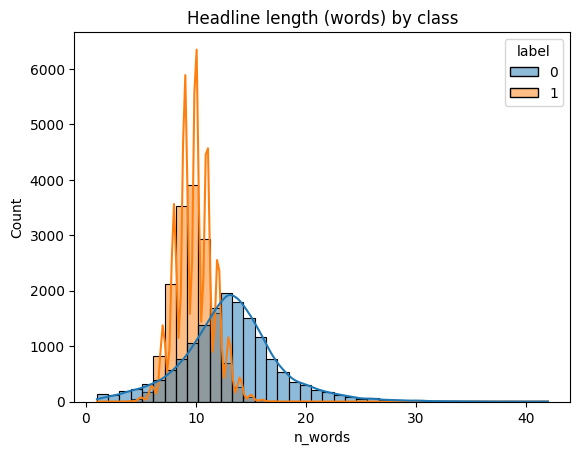

In [4]:
# How balanced are the two classes?
ax = df_train['label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['Fake (0)', 'Real (1)'], rotation=0)
ax.set_title('Class distribution')
plt.show()

# How long are the headlines, and does it differ by class?
df_train['n_words'] = df_train['headline'].str.split().str.len()
sns.histplot(data=df_train, x='n_words', hue='label', bins=40, kde=True)
plt.title('Headline length (words) by class')
plt.show()

---
# 3. Preprocessing

In [5]:
STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
PUNCT_RE = re.compile(f'[{re.escape(string.punctuation)}0-9]')


def clean_text(text: str) -> str:
    """Lowercase, strip punctuation/digits, drop stopwords, lemmatise."""
    text = text.lower()
    text = PUNCT_RE.sub(' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# Quick check on a noisy example
clean_text("Donald Trump sends out EMBARRASSING tweets!!! #fakenews")

'donald trump sends embarrassing tweet fakenews'

In [6]:
df_train['processed_text'] = df_train['headline'].apply(clean_text)
df_test['processed_text'] = df_test['headline'].apply(clean_text)

df_train[['headline', 'processed_text', 'label']]

,headline,processed_text,label
0,donald trump sends out embarrassing new year‚s eve message; this is disturbing,donald trump sends embarrassing new year‚s eve message disturbing,0
1,drunk bragging trump staffer started russian collusion investigation,drunk bragging trump staffer started russian collusion investigation,0
2,sheriff david clarke becomes an internet joke for threatening to poke people ‚in the eye‚,sheriff david clarke becomes internet joke threatening poke people ‚in eye‚,0
3,trump is so obsessed he even has obama‚s name coded into his website (images),trump obsessed even obama‚s name coded website image,0
4,pope francis just called out donald trump during his christmas speech,pope francis called donald trump christmas speech,0
...,...,...,...
32201,tears in rain as thais gather for late king's funeral,tear rain thai gather late king funeral,1
32202,pyongyang university needs non-u.s. teachers as travel ban leaves staff shortages,pyongyang university need non teacher travel ban leaf staff shortage,1
32203,philippine president duterte to visit japan ahead of key regional summits,philippine president duterte visit japan ahead key regional summit,1
32204,japan's abe may have won election\tbut many don't want him as pm,japan abe may election many want pm,1


---
# 4. Training the models

## Train / Test Split

In [ ]:
# Target labels (0 = Fake, 1 = Real)
y_target = df_train['label']

# Split for Raw text
Xraw_train, Xraw_test, y_train, y_test = train_test_split(
    df_train['headline'], y_target, test_size=0.20, random_state=42
)

# Split for Cleaned text
Xclean_train, Xclean_test, _, _ = train_test_split(
    df_train['processed_text'], y_target, test_size=0.20, random_state=42
)

# Aliases used by the downstream evaluation cells
X_train, X_test = Xclean_train, Xclean_test

print(f"-> Training set: {len(Xraw_train)} samples")
print(f"-> Test set: {len(Xraw_test)} samples")

---
# 5. Feature engineering

## Defining pipelines

In [ ]:
# Define pipelines for different vectorizer + classifier combinations (8 combinations)
experiments = [
    # 1. Naive Bayes
    ("Raw + BoW + Naive Bayes",   Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB())]), Xraw_train, Xraw_test),
    ("Clean + BoW + Naive Bayes", Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB())]), Xclean_train, Xclean_test),
    
    # 2. Logistic Regression
    ("Raw + TF-IDF + LR", Pipeline([('vec', TfidfVectorizer()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]), Xraw_train, Xraw_test),
    ("Clean + TF-IDF + LR", Pipeline([('vec', TfidfVectorizer()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]), Xclean_train, Xclean_test),
    
    # 3. Random Forest
    ("Raw + TF-IDF + Random Forest", Pipeline([('vec', TfidfVectorizer()), ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]), Xraw_train, Xraw_test),
    ("Clean + TF-IDF + Random Forest", Pipeline([('vec', TfidfVectorizer()), ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]), Xclean_train, Xclean_test),
    
    # 4. Linear SVM
    ("Raw + TF-IDF + SVM", Pipeline([('vec', TfidfVectorizer()), ('clf', LinearSVC(random_state=42))]), Xraw_train, Xraw_test),
    ("Clean + TF-IDF + SVM", Pipeline([('vec', TfidfVectorizer()), ('clf', LinearSVC(random_state=42))]), Xclean_train, Xclean_test)
]

## Train and evaluate Pipelines, check overfitting

In [ ]:
print("Testing combinations pipelines (Checking Train vs Test Accuracy)...\n")

results_names = []
train_accuracies = []
val_accuracies = []
best_baseline_acc = 0

for name, pipeline, X_train_set, X_val_set in experiments:
    print(f"Training {name}...")
    pipeline.fit(X_train_set, y_train)
    
    # Calculate scores
    train_acc = accuracy_score(y_train, pipeline.predict(X_train_set))
    val_acc = accuracy_score(y_test, pipeline.predict(X_val_set))
    
    # Prepare plot
    results_names.append(name)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"   Score -> Train: {train_acc:.4f} | Val: {val_acc:.4f}")
    
    if val_acc > best_baseline_acc:
        best_baseline_acc = val_acc
        best_baseline_name = name

print(f"\n-----> BEST BASELINE COMBINATION: {best_baseline_name} ({best_baseline_acc:.4f})")

## Models Comparison chart
Comparing with/without preprocessing

In [ ]:
# Make the figure slightly wider to accommodate 8 labels
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting Training vs Validation to show Overfitting
ax.plot(results_names, train_accuracies, marker='o', color='#3498db', label='Training Accuracy', linewidth=2, markersize=8)
ax.plot(results_names, val_accuracies, marker='s', color='#e74c3c', label='Validation Accuracy', linewidth=2, markersize=8)

# Formatting
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title('Exhaustive Impact of Preprocessing & Model Selection', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)

# Adjust X-axis labels to prevent overlap
plt.xticks(rotation=35, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=11)

best_idx = np.argmax(val_accuracies)
print(f"\nBEST CONFIGURATION: {results_names[best_idx]} with {val_accuracies[best_idx]*100:.2f}% Accuracy")

plt.tight_layout()
plt.savefig('group1_model_comparison.png', dpi=150)
plt.show()

## Hyperparameter Tuning (GridSearchCV)
Optimizing our Best Model (Raw + TF-IDF + SVM)

In [ ]:
# Define the grid search on the best configuration (Cleaned text + TF-IDF + SVM)
pipe_to_tune = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LinearSVC(random_state=42))
])

param_grid = {
    'vec__ngram_range': [(1, 1), (1, 2)],
    'vec__max_features': [None, 5000],
    'clf__C': [0.01, 0.05, 0.1, 0.5, 1, 10]
}

print("Running GridSearchCV...")
grid_search = GridSearchCV(pipe_to_tune, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(Xraw_train, y_train)

# Extract Scores
tuned_test_acc = accuracy_score(y_test, grid_search.predict(Xraw_test))

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Tuned Model Validation Accuracy: {tuned_test_acc:.4f}")

# Recalculate baseline for the graph comparison
baseline_pipe = Pipeline([("vec", TfidfVectorizer()), ("clf", LinearSVC(random_state=42))])
baseline_pipe.fit(Xraw_train, y_train)
baseline_acc = accuracy_score(y_test, baseline_pipe.predict(Xraw_test))

### VISUALIZATION: TUNING IMPACT

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

# Create bars
bars = ax.bar(['Baseline SVM\n(Default Params)', 'Tuned SVM\n(GridSearchCV)'], 
              [baseline_acc, tuned_test_acc], 
              color=['#34495e', '#f1c40f'],
              width=0.5)

ax.set_ylim(0.92, 0.96) 
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Impact of Hyperparameter Tuning', fontsize=14, fontweight='bold')

# Percentages on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f"{yval*100:.2f}%", 
            ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('group1_tuning_impact.png', dpi=150)
plt.show()

## Export Pipeline

In [ ]:
final_best_model = grid_search.best_estimator_
output_filename = 'pipeline_best_model.pkl'

with open(output_filename, 'wb') as file:
    pickle.dump(final_best_model, file)
    
print(f"\nTuned pipeline successfully exported as saved as '{output_filename}'")

---
# 6. Evaluation
Now that Philippe's model is trained, my job is to measure how well it actually works and understand where it makes mistakes.

Metrics I'll compute:
- **Accuracy** — overall % of correct predictions
- **Precision** — of the headlines predicted as Real, how many actually are?
- **Recall** — of all actual Real headlines, how many did we catch?
- **F1** — harmonic mean of Precision and Recall (best single-number summary)
- **Confusion Matrix** — visual breakdown of TP, TN, FP, FN

In [ ]:
# Step 1: Load the model Philippe saved

with open('pipeline_best_model.pkl', 'rb') as f:
    model_pipeline = pickle.load(f)

print(" Model loaded successfully!")
print(f"Pipeline steps: {[step[0] for step in model_pipeline.steps]}")

In [ ]:
# Step 2: Generate predictions on the validation set

y_pred = model_pipeline.predict(X_test)

print(f"Predictions generated: {len(y_pred)} samples")

In [ ]:
#Step 3: Compute the core metrics

# accuracy_score: (correct predictions) / (total predictions)
acc = accuracy_score(y_test, y_pred)

# precision_score: of the headlines we predicted as Real (1),

prec = precision_score(y_test, y_pred)

# recall_score: of all the Real (1) headlines in the dataset,

rec = recall_score(y_test, y_pred)

# f1_score: combines precision and recall into one number.

f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("EVALUATION RESULTS")
print("=" * 40)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")

In [ ]:
# Step 4: Full classification report

print("CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Fake News (0)', 'Real News (1)']
))

In [ ]:
# Step 5: Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,                          
    fmt='d',                            
    cmap='Blues',                        
    xticklabels=['Fake (0)', 'Real (1)'],
    yticklabels=['Fake (0)', 'Real (1)'],
    ax=ax
)
ax.set_title('Confusion Matrix — Best Model', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(" Saved as 'confusion_matrix.png'")

In [ ]:
# Step 6: Error analysis — look at what the model got wrong

eval_df = pd.DataFrame({
    'headline' : X_test.values,    # Original (unprocessed) headline text
    'true'     : y_test.values,    # Correct label (0 or 1)
    'predicted': y_pred            # What the model predicted
})

# Filter for rows where the model was wrong
misclassified = eval_df[eval_df['true'] != eval_df['predicted']]

print(f"Total misclassifications: {len(misclassified)} out of {len(eval_df)} "
      f"({len(misclassified)/len(eval_df)*100:.1f}%)")
print()

In [ ]:
# False Negatives: model predicted Fake (0) but headline was actually Real (1)

false_negatives = misclassified[misclassified['true'] == 1].head(5)
print("=== Real headlines the model thought were FAKE (False Negatives) ===")
for _, row in false_negatives.iterrows():
    print(f"  '{row['headline']}'")
print()

In [ ]:
# False Positives: model predicted Real (1) but headline was actually Fake (0)

false_positives = misclassified[misclassified['true'] == 0].head(5)
print("=== Fake headlines the model thought were REAL (False Positives) ===")
for _, row in false_positives.iterrows():
    print(f"  '{row['headline']}'")

---
# 7. Predicting on the test set
Now we apply the model to the real test set — the one with no labels.
This is what we submit.

Key rules:
- Use Sabeur's `clean_text()` on the test headlines (same preprocessing as training)
- Use Philippe's already-fitted `model_pipeline` — **no refitting**
- Only call `.predict()` — never `.fit()` on test data

In [ ]:
# Step 1: Verify the test data is ready

print(f"Test set size: {len(df_test)} headlines")
print()
print("Preview of test data:")
df_test[['headline', 'processed_text']].head()

In [ ]:
# Step 2: Generate predictions


test_predictions = model_pipeline.predict(df_test['processed_text'])

# Quick sanity check: distribution of predictions
unique, counts = np.unique(test_predictions, return_counts=True)
print(f"Predictions generated: {len(test_predictions)}")
print()
for label, count in zip(unique, counts):
    name = 'Fake' if label == 0 else 'Real'
    print(f"  Predicted {name} ({label}): {count} headlines ({count/len(test_predictions)*100:.1f}%)")

---
# 8. Final output
Two deliverables:
1. `submission.csv` — predictions for every test headline, in order
2. `model_pipeline.joblib` — the saved pipeline for reproducibility

In [ ]:
# Deliverable 1: submission.csv


submission = pd.DataFrame({'prediction': test_predictions})

submission.to_csv('submission.csv', index=False)

print(" submission.csv saved!")
print()
print("Preview:")
print(submission.head(10))

In [ ]:
# Deliverable 2: model_pipeline.joblib

joblib.dump(model_pipeline, 'model_pipeline.joblib')

print(" model_pipeline.joblib saved!")

In [ ]:
# Final Summary

print("=" * 55)
print("FAKE NEWS DETECTION — FINAL SUMMARY")
print("=" * 55)
print()
print("Dataset")
print(f"  Training samples   : {len(X_train)}")
print(f"  Validation samples : {len(X_test)}")
print(f"  Test samples       : {len(df_test)}")
print()
print("Best Model")
print(f"  Pipeline           : TF-IDF + Linear SVM (tuned with GridSearchCV)")
print(f"  Validation Accuracy: {acc*100:.2f}%")
print(f"  Precision          : {prec:.4f}")
print(f"  Recall             : {rec:.4f}")
print(f"  F1 Score           : {f1:.4f}")
print()
print("Output files")
print("   submission.csv         → Test set predictions (0=Fake, 1=Real)")
print("   model_pipeline.joblib  → Saved model for reproducibility")
print("   confusion_matrix.png   → Confusion matrix chart")

---
# 9. Wrap-up and ideas for later

What we ended up with: a small, reproducible pipeline that cleans headlines, turns them into TF-IDF features, runs them through a classifier, and spits out predictions for the unlabelled test set.

Things we could try if we had more time:
- Word embeddings (Word2Vec, GloVe) instead of TF-IDF.
- A pretrained transformer (BERT or RoBERTa) for the heavy-lifting baseline.
- A tiny Streamlit app so anyone can paste a headline and get a verdict.
- Tracking how accuracy holds up over time or across topics.

Teamwork makes the model work.